In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/ahcd1/Train+Test Images Matlab.mat
/kaggle/input/ahcd1/csvTestLabel 3360x1.csv
/kaggle/input/ahcd1/csvTrainImages 13440x1024.csv
/kaggle/input/ahcd1/csvTestImages 3360x1024.csv
/kaggle/input/ahcd1/csvTrainLabel 13440x1.csv
/kaggle/input/ahcd1/Arabic Handwritten Characters Dataset CSV/csvTestLabel 3360x1.csv
/kaggle/input/ahcd1/Arabic Handwritten Characters Dataset CSV/csvTrainImages 13440x1024.csv
/kaggle/input/ahcd1/Arabic Handwritten Characters Dataset CSV/csvTestImages 3360x1024.csv
/kaggle/input/ahcd1/Arabic Handwritten Characters Dataset CSV/csvTrainLabel 13440x1.csv
/kaggle/input/ahcd1/arabic handwritten characters dataset csv/csvTestLabel 3360x1.csv
/kaggle/input/ahcd1/arabic handwritten characters dataset csv/csvTrainImages 13440x1024.csv
/kaggle/input/ahcd1/arabic handwritten characters dataset csv/csvTestImages 3360x1024.csv
/kaggle/input/ahcd1/arabic handwritten characters dataset csv/csvTrainLabel 13440x1.csv
/kaggle/input/ahcd1/Train Images 13440x32x32/train/

In [2]:
# ================================
# Step 1: Import Libraries
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models

2025-09-11 19:20:02.711991: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1757618403.086061      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1757618403.192617      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
# ================================
# Step 2: Load Dataset
# ================================
train_images = pd.read_csv("/kaggle/input/ahcd1/csvTrainImages 13440x1024.csv")
train_labels = pd.read_csv("/kaggle/input/ahcd1/csvTrainLabel 13440x1.csv")

test_images = pd.read_csv("/kaggle/input/ahcd1/csvTestImages 3360x1024.csv")
test_labels = pd.read_csv("/kaggle/input/ahcd1/csvTestLabel 3360x1.csv")

# Labels start from 1 → shift to 0-27
y = train_labels.values.flatten() - 1
y_test = test_labels.values.flatten() - 1

# Normalize (0-255 → 0-1)
X_full = train_images.values.astype("float32") / 255.0
X_test = test_images.values.astype("float32") / 255.0

# Split Train → Train + Validation
X_train, X_val, y_train, y_val = train_test_split(
    X_full, y, test_size=0.1, random_state=42, stratify=y
)

print("Training data shape:", X_train.shape)   # (12096, 1024)
print("Validation data shape:", X_val.shape)   # (1344, 1024)
print("Test data shape:", X_test.shape)        # (3360, 1024)

Training data shape: (12095, 1024)
Validation data shape: (1344, 1024)
Test data shape: (3359, 1024)


In [4]:
# ================================
# Step 3: Reshape Data
# ================================
# For CNN → (32, 32, 1)
X_train_cnn = X_train.reshape(-1, 32, 32, 1)
X_val_cnn   = X_val.reshape(-1, 32, 32, 1)
X_test_cnn  = X_test.reshape(-1, 32, 32, 1)

# For DNN → Keep Flattened (n, 1024)
X_train_dnn = X_train
X_val_dnn   = X_val
X_test_dnn  = X_test

# Model 1


In [5]:
# ================================
# Step 4: Build CNN Model
# ================================
model_cnn1 = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32, 32, 1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(28, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1757618423.601240      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1757618423.601888      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [6]:
model_cnn1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model 2

In [7]:
# ================================
# Step 5: Build DNN Model
# ================================
model_dnn = models.Sequential([
    layers.Input(shape=(1024,)),   # بدل Flatten
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(28, activation='softmax')
])

In [8]:
model_dnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
# ================================
# Step 6: Train Models
# ================================
history_cnn = model_cnn1.fit(
    X_train_cnn, y_train,
    epochs=20, batch_size=128,
    validation_data=(X_val_cnn, y_val),
    verbose=1
)

history_dnn = model_dnn.fit(
    X_train_dnn, y_train,
    epochs=20, batch_size=128,
    validation_data=(X_val_dnn, y_val),
    verbose=1
)

Epoch 1/20


I0000 00:00:1757618428.635234      63 service.cc:148] XLA service 0x79b6bc00c5c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1757618428.636639      63 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1757618428.636657      63 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1757618429.047918      63 cuda_dnn.cc:529] Loaded cuDNN version 90300


36/95 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0606 - loss: 3.2484

I0000 00:00:1757618433.712087      63 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


95/95 ━━━━━━━━━━━━━━━━━━━━ 12s 46ms/step - accuracy: 0.1195 - loss: 2.9928 - val_accuracy: 0.5491 - val_loss: 1.4838
Epoch 2/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4826 - loss: 1.5298 - val_accuracy: 0.7262 - val_loss: 0.8056
Epoch 3/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6726 - loss: 0.9490 - val_accuracy: 0.8028 - val_loss: 0.6113
Epoch 4/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7763 - loss: 0.6568 - val_accuracy: 0.8482 - val_loss: 0.4394
Epoch 5/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8267 - loss: 0.4981 - val_accuracy: 0.8728 - val_loss: 0.4075
Epoch 6/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8589 - loss: 0.4063 - val_accuracy: 0.8824 - val_loss: 0.3565
Epoch 7/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8908 - loss: 0.3192 - val_accuracy: 0.9077 - val_loss: 0.3083
Epoch 8/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9138 - loss: 0.2740 - val_accuracy: 0.8921 - val_loss: 0.3215
E

In [10]:
# ================================
# Step 7: Evaluate on Test Set
# ================================
test_loss_cnn, test_acc_cnn = model_cnn1.evaluate(X_test_cnn, y_test, verbose=0)
test_loss_dnn, test_acc_dnn = model_dnn.evaluate(X_test_dnn, y_test, verbose=0)

print("✅ CNN Test Accuracy:", test_acc_cnn)
print("✅ DNN Test Accuracy:", test_acc_dnn)

✅ CNN Test Accuracy: 0.9395653605461121
✅ DNN Test Accuracy: 0.7713605165481567


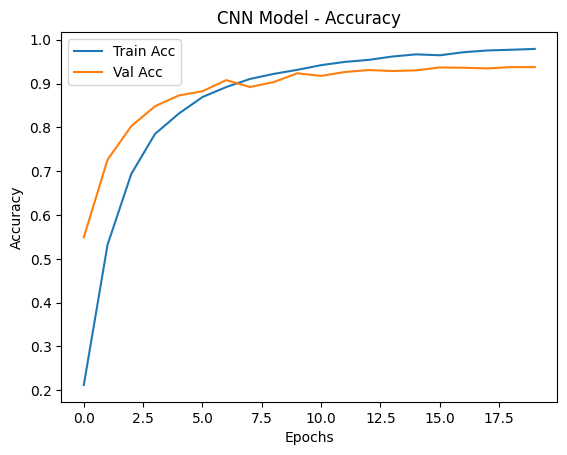

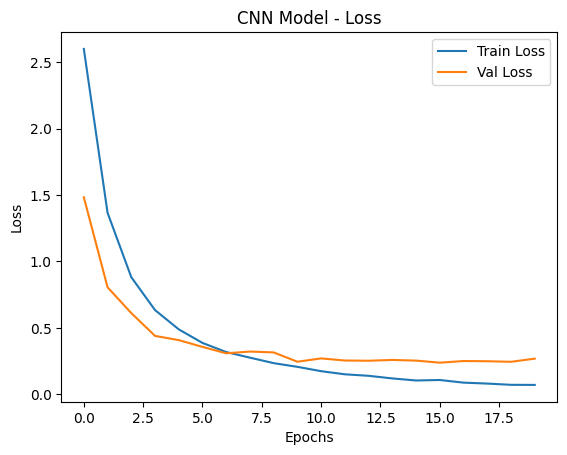

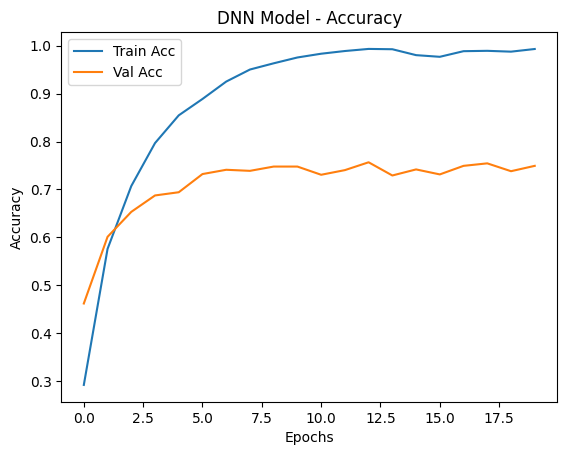

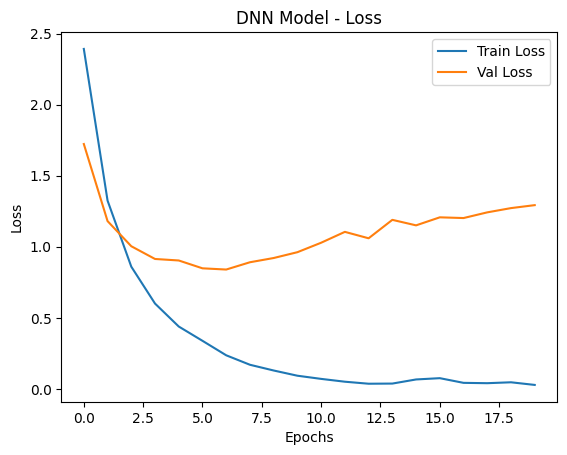

In [11]:
# ================================
# Step 8: Plot Training Curves
# ================================
def plot_history(history, title):
    # Accuracy
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title(title + " - Accuracy")
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

    # Loss
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(title + " - Loss")
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()


# CNN Plots
plot_history(history_cnn, "CNN Model")

# DNN Plots
plot_history(history_dnn, "DNN Model")

105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


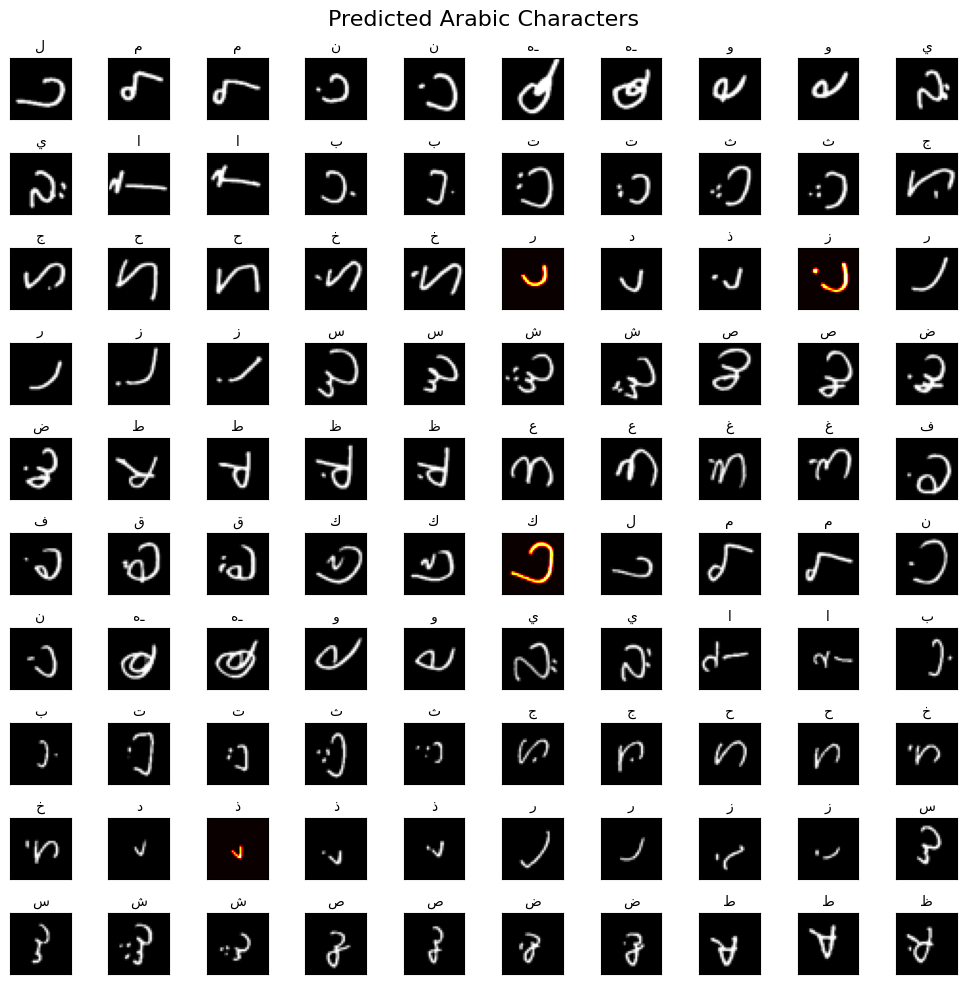

In [12]:
# ================================
# Visualization of Predictions
# ================================
import matplotlib.pyplot as plt
import numpy as np

numeric_arabic = {
    1: "ا", 2: "ب", 3: "ت", 4: "ث", 5: "ج",
    6: "ح", 7: "خ", 8: "د", 9: "ذ", 10: "ر",
    11: "ز", 12: "س", 13: "ش", 14: "ص", 15: "ض",
    16: "ط", 17: "ظ", 18: "ع", 19: "غ", 20: "ف",
    21: "ق", 22: "ك", 23: "ل", 24: "م", 25: "ن",
    26: "هـ", 27: "و", 28: "ي"
}

n = 100
shift = 100
rows = int(np.ceil(np.sqrt(n)))
cols = int(np.ceil(n / rows))

predictions = model_cnn1.predict(X_test_cnn)   # أو model_dnn + X_test_dnn
predictions_Test = np.argmax(predictions, axis=1)
y_true = y_test   # labels جاهزة

plt.figure(figsize=(cols*1, rows*1))
plt.suptitle('Predicted Arabic Characters', fontsize=16)

for i in range(n):
    plt.subplot(rows, cols, i+1)
    plt.xticks([])
    plt.yticks([])

    # العنوان: الحرف المتوقع
    plt.title(numeric_arabic[predictions_Test[i+shift]+1], fontsize=10)

    # لو التنبؤ غلط → صورة بالـ hot
    if y_true[i+shift] != predictions_Test[i+shift]:
        plt.imshow(X_test_cnn[i+shift].reshape(32,32), cmap="hot")
    else:
        plt.imshow(X_test_cnn[i+shift].reshape(32,32), cmap="gray")

plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()